mask_repeat_candidates.pkl:   0%|          | 0.00/31.3M [00:00<?, ?B/s]

<class 'torch.Tensor'>
torch.Size([104091, 301])
torch.bool
False
True ratio: 0.012172169052064419
False ratio: 0.9878278309479356


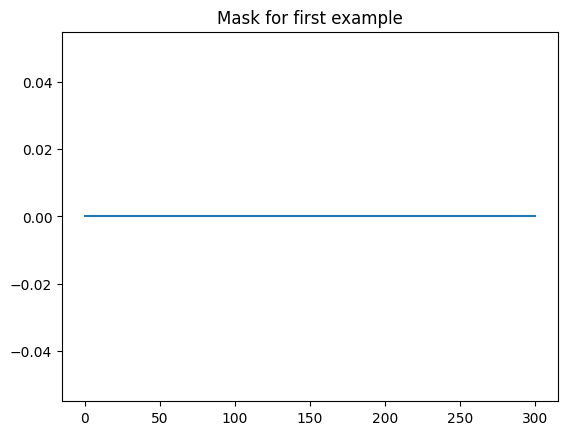

validation_data.pt:   0%|          | 0.00/125M [00:00<?, ?B/s]

torch.Size([104091, 301]) torch.Size([104091, 301])


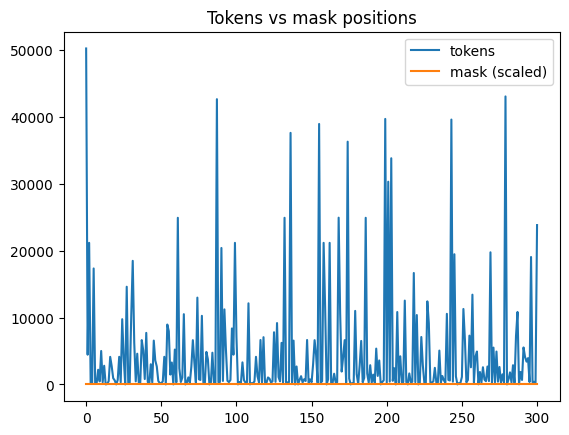

In [3]:
import torch
import huggingface_hub

fname = huggingface_hub.hf_hub_download(
    repo_id="ArthurConmy/redwood_attn_2l",
    filename="mask_repeat_candidates.pkl"
)

mask = torch.load(fname, map_location="cpu")

print(type(mask))
print(mask.shape)
print(mask.dtype)
print(mask.requires_grad)

print("True ratio:", mask.float().mean().item())
print("False ratio:", 1 - mask.float().mean().item())

import matplotlib.pyplot as plt

plt.plot(mask[0].numpy())
plt.title("Mask for first example")
plt.show()

data_fname = huggingface_hub.hf_hub_download(
    repo_id="ArthurConmy/redwood_attn_2l",
    filename="validation_data.pt"
)

data = torch.load(data_fname, map_location=torch.device('cpu'))

print(data.shape, mask.shape)

i = 0

plt.figure()
plt.plot(data[i].numpy(), label="tokens")
plt.plot((mask[i] * data[i].max()).numpy(), label="mask (scaled)")
plt.legend()
plt.title("Tokens vs mask positions")
plt.show()


In [17]:
import torch
import transformers
import os

i = 3

true_positions = torch.where(mask[i])[0]

print("Positions with True:")
print(true_positions.tolist())

os.environ["TRANSFORMERS_USE_FAST"] = "True"

orig_auto = transformers.AutoTokenizer.from_pretrained
orig_gpt2 = transformers.GPT2Tokenizer.from_pretrained
orig_gpt2_fast = transformers.GPT2TokenizerFast.from_pretrained

def universal_tokenizer_patch(orig_fn):
    def patched_fn(pretrained_model_name_or_path, *args, **kwargs):
        if (
            isinstance(pretrained_model_name_or_path, str)
            and "redwood" in pretrained_model_name_or_path.lower()
        ):
            pretrained_model_name_or_path = "gpt2"

        kwargs["use_fast"] = True
        return orig_fn(pretrained_model_name_or_path, *args, **kwargs)

    return patched_fn

transformers.AutoTokenizer.from_pretrained = universal_tokenizer_patch(orig_auto)
transformers.GPT2Tokenizer.from_pretrained = universal_tokenizer_patch(orig_gpt2)
transformers.GPT2TokenizerFast.from_pretrained = universal_tokenizer_patch(orig_gpt2_fast)
tokenizer = transformers.AutoTokenizer.from_pretrained(
    "ArthurConmy/redwood_tokenizer"
)

for p in true_positions:
    p = p.item()

    token_id = int(data[i, p].item())
    token = tokenizer.decode([token_id])

    print(f"Position : {p:4d} | Token id : {token_id:6d} | Token text : {repr(token)}")

Positions with True:
[55, 57, 124, 152, 168, 170, 173, 174, 262, 263, 298, 299]
Position :   55 | Token id :  42168 | Token text : ' Samp'
Position :   57 | Token id :  21939 | Token text : ' Flat'
Position :  124 | Token id :   7080 | Token text : ' Mach'
Position :  152 | Token id :   7080 | Token text : ' Mach'
Position :  168 | Token id :  42168 | Token text : ' Samp'
Position :  170 | Token id :  21939 | Token text : ' Flat'
Position :  173 | Token id :   1770 | Token text : ' Mr'
Position :  174 | Token id :   7080 | Token text : ' Mach'
Position :  262 | Token id :   1770 | Token text : ' Mr'
Position :  263 | Token id :   7080 | Token text : ' Mach'
Position :  298 | Token id :   1770 | Token text : ' Mr'
Position :  299 | Token id :   7080 | Token text : ' Mach'
